In [26]:
# Load dependency
from QC_FCS_prep_utils import *
from QC_flow_cyto_utils import *

import warnings
warnings.filterwarnings('ignore')

### FCS file parsing and gating

The demo FCS file is used as an example to show the gating strategy (as shown in Supplementary figure S1).  
The demo FCS file is named as '61-F-1'. It is one replicate of v0-phosphoGal4 response in growth media condition. 


In [27]:
# get root path of the folder containing ONLY FCS files
root = '/Users/cqh/Desktop/supplement_figs/supp_fig2/'
fcs_path = root+'FCSs_comp' #this folder should have both comped and uncomped data in the FCS files

# Make a new folder to store gated figures
gate_res_path = root+'gate_res'
if not os.path.isdir(gate_res_path):
        os.makedirs(gate_res_path)

# Make a new folder to store all dfs from individual gating process
df_path = root+'df'
if not os.path.isdir(df_path):
        os.makedirs(df_path)

In [28]:
exp = '61-f - 1'

# Load this exp
s, outPath = load_FSC(exp, fcs_path, gate_res_path)

# Gate for FSC-A and SSC-A
s_g1 = FSC_SSC_eclipse_gating(s, outPath, ch=['FSC-A', 'SSC-A'], center=(3.3e5, 1.8e5), a=1.9e5, b=1.5e5, theta=30/180.*np.pi,
                        density_params={'mode':'scatter', 'xscale':'linear', 
                                    'yscale':'linear', 'xlim':[0, 1e6],
                                    'ylim':[1, 1e6], 'smooth':False},
                        hist_channels=['SSC-A'],
                        hist_params={'bins':512, 'xlim':[1e4, 1e6]},
                        fig_size=[5,10], save_fig=True)

# Gate for FSC-A and FSC-H
s_g2 = FSC_SSC_eclipse_gating(s_g1, outPath, ch=['FSC-A', 'FSC-H'], center=(3.3e5, 1.7e5), a=2.1e5, b=0.7e5, theta=20/180.*np.pi,
                            density_params={'mode':'scatter', 'xscale':'linear', 
                                        'yscale':'linear', 'xlim':[1, 1e6],
                                        'ylim':[1, 1e6], 'smooth':False},
                            hist_channels=['FSC-H'],
                            hist_params={'bins':512, 'xlim':[1e4, 1e6]},
                            fig_size=[5,10], save_fig=True)

# Gate for high expressing iRFP
s_g3 = FL_high_low_gating(s_g2, outPath, channels='FJComp-FL5-A',
                        high=2e5, low=1e4, hist_bins=256,
                        save_fig=True)

# Save the data to a df for each of the tube/exp/condition
df = data_extraction(s_g3, exp, df_path)

# NOTE: all gating function generate a plot for gating resuls as shown in size-gating, single cell gating and iRFP gating (as shown in Supplementary figure S1)

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

### 2D scatter plot to visualize FCS files

In [29]:
# Read the combined csv
df = pd.read_csv(df_path+'/combined.csv')

# Get the plasmid name as a column
df['plasmid'] = [x.split('-')[0] for x in df['string']]
df['cond'] = [x.split('-')[1].strip() for x in df['string']]
df['rep'] = [int(x.split('-')[2].strip()) for x in df['string']]

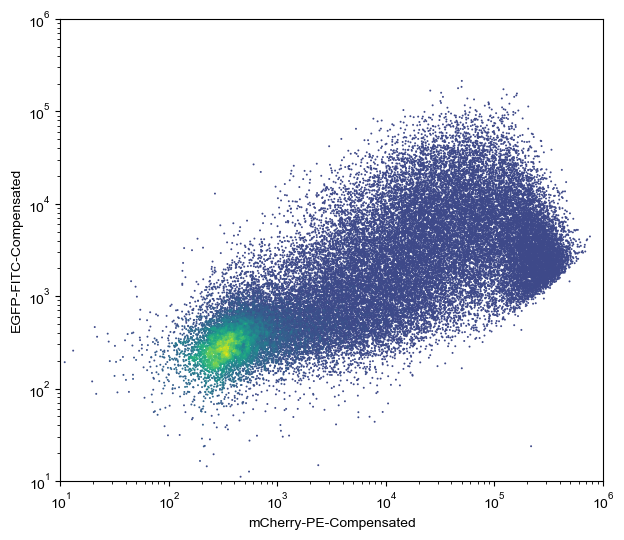

In [30]:
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

plt.figure(figsize=(7, 6))

# Define the experiment and filter the data
exp = '61-F - 1'
tmp = df[df['string'] == exp]

# Create a k-d tree for efficient neighbor searching
tree = cKDTree(tmp[['FJComp-FL3-A', 'FJComp-FL2-A']].values)

# Define radius
radius = 20

# Compute the number of neighbors for each cell
neighbor_counts = tree.query_ball_tree(tree, r=radius)
tmp['neighbors'] = [len(neighbors) - 1 for neighbors in neighbor_counts]  # Exclude self

# Normalize the 'neighbors' column for consistent color scaling
norm = mcolors.Normalize(vmin=tmp['neighbors'].min()-20, vmax=tmp['neighbors'].max())

# Sort DataFrame by 'neighbors' in descending order
tmp_sorted = tmp.sort_values(by='neighbors', ascending=False)

# Plot a 2D scatterplot with jointplot
g = sns.scatterplot(
    data=tmp,
    x="FJComp-FL3-A",
    y="FJComp-FL2-A",
    hue="neighbors",
    palette='viridis',
    s=2,
    alpha=1,  # Adjust transparency for better visualization
    edgecolor='none',  # Remove edges
    hue_norm=norm  # Apply normalization
)

# Set log scale for both axes
g.set_xscale('log')
g.set_yscale('log')

# Optionally, set axis limits if needed
g.set_xlim([1e1, 1e6])
g.set_ylim([1e1, 1e6])

# get rid of the legend
g.legend_.remove()

# Set axis labels
g.set_xlabel('mCherry-PE-Compensated')
g.set_ylabel('EGFP-FITC-Compensated')

plt.show()

### Binned 2D curve to visualize FCS files

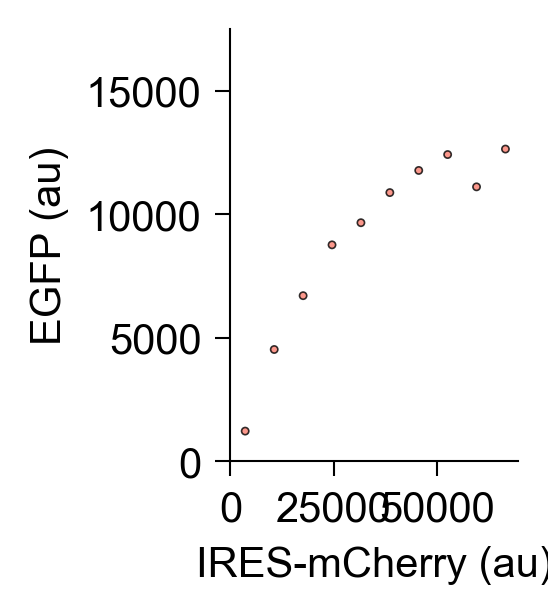

In [31]:
# Crop and bin the data
bins = 10
high_lim = 7e4
low_lim = 1e2

# bin the cells by their mCherry expression level (FJComp-FL3-A)
df = data_crop_and_bin(df, crop_bin_ch='FJComp-FL3-A', 
                       bins=bins, high_lim=high_lim, low_lim=low_lim)  # fxn in QC_flow_cyto_utils
exp = '61-F - 1'
tmp = df[df['string'] == exp]

# get the mean of EGFP (FJComp-FL2-A) for each bin
tmp = tmp.groupby(['string', 'mid'])['FJComp-FL2-A'].mean().to_frame()
tmp = tmp.reset_index(level=[0,1])
tmp['plasmid'] = [a.split('-')[0] for a in tmp['string']]

# set canvas/fig size
# NOTE: figwidth is calculated with the function
fig_height = 1.8
fig_width = 1.2

f = plt.figure(figsize=[fig_width, fig_height], dpi=300)

# set grid size
gs1 = f.add_gridspec(1, 1, left=0.1, right=0.9, top=0.9, bottom=0.1)    # default, do not change
ax = f.add_subplot(gs1[0])

# Set font size
plt.rcParams['font.size'] = '10'
plt.rcParams["font.family"]  = 'Arial'

# Define the custom color palette
palette = ['#FA7F6F', '#D633A6',]

# Plot the data points of each experiment
sns.scatterplot(tmp, x='mid', y='FJComp-FL2-A', hue='plasmid',
        marker="o", palette=palette,
        alpha=0.8, edgecolor='k', linewidth=0.4, s=3, ax=ax,zorder=2)


# change general settings
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.5)
ax.tick_params(which='both', width=0.5)
ax.spines[['right', 'top']].set_visible(False)

# Set axis information
# For x axis
ax.set_ylim([1e2, 7e4])
ax.set_xlabel('IRES-mCherry (au)')

# # For y axis
ax.set_ylim([0, 1.75e4])
ax.set_ylabel('EGFP (au)')

# # Following is for aesthetics
ax.set_xticks([0, 25000, 50000])
ax.set_yticks([0, 5000, 10000, 15000])

# remove legend
ax.get_legend().remove()


### mCherry gating histograms to show mCherry gating strategy

####  histogram of mcherry channel to show the gate

In [32]:
# Read the combined csv
df = pd.read_csv(df_path+'/combined.csv')

# Get the plasmid name as a column
df['plasmid'] = [x.split('-')[0] for x in df['string']]
df['cond'] = [x.split('-')[1].strip() for x in df['string']]
df['rep'] = [int(x.split('-')[2].strip()) for x in df['string']]

# only get this experiment's data
df_bar = df[df['string'] == '61-F - 1']

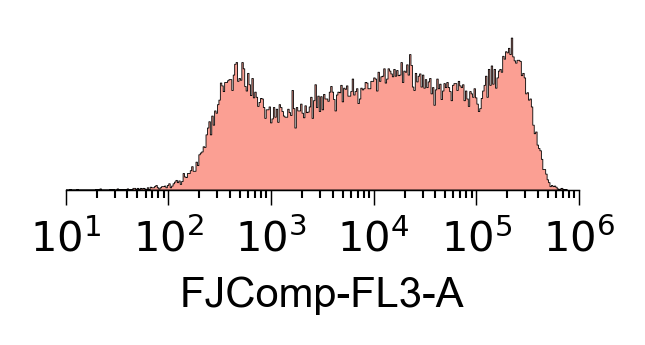

In [33]:
# Set font style
plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = 'Arial'

# Define colors for each plasmid
color =  "#FA7F6F"

# Create figure with 3 subplots, reduce vertical spacing even further
fig, axes = plt.subplots(1, 1, figsize=(2.25, 1.25), dpi=300, sharex=True)
fig.subplots_adjust(hspace=0.05)  # Reduce spacing between subplots

ax = axes

# Subset data for mCherry (FJComp-FL3-A)
data = df_bar["FJComp-FL3-A"]
    
# KDE Plot
sns.histplot(data, ax=ax, color=color, fill=True, log_scale=True,
            linewidth=.2, bins=400,element='step', edgecolor='black')
    
# Remove y-ticks and spines
ax.set_yticks([])
ax.set_ylabel("")
ax.spines[['right', 'top', 'left']].set_visible(False)
    
# Set x-axis limits
ax.set_xlim(1e2, 1e6)  # Ensures all subplots have the same x-range

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(0.35)
ax.tick_params(which='both', width=0.35)

# Format only the bottom subplot's x-axis
ax.set_xscale("log")
ax.set_xticks([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
ax.set_xticklabels([r"$10^1$",r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"])
ax.set_xlabel("FJComp-FL3-A")

# Add minor ticks for finer scale (e.g., 1.1e2)
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.linspace(0.1, 0.9, 9), numticks=10))
ax.tick_params(which='minor', length=2, width=0.5)

plt.tight_layout()
plt.show()

####  Histogram of UAS-EGFP response after mCherry gating

In [34]:
# Define a region of high mCherry expression to calculate fold change
high_lim = 6e4
low_lim = 5e4

df_bar = df[df['FJComp-FL3-A']<=high_lim]
df_bar = df_bar[df_bar['FJComp-FL3-A']>=low_lim]

# only get this experiment's data
df_bar = df_bar[df_bar['string'] == '61-F - 1']


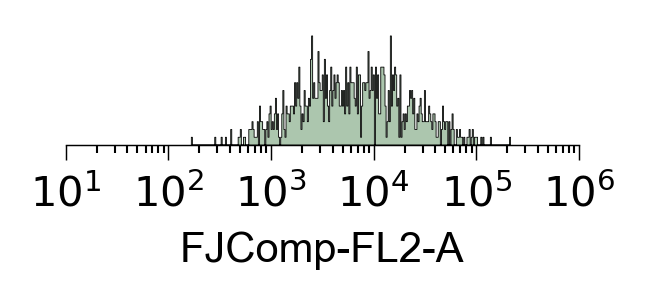

In [ ]:


# Set font style
plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = 'Arial'

# Define colors for each plasmid
color =  '#91B493' 

# Create figure with 3 subplots, reduce vertical spacing even further
fig, axes = plt.subplots(1, 1, figsize=(2.25, 1.1), dpi=300, sharex=True)
fig.subplots_adjust(hspace=0.05)  # Reduce spacing between subplots

ax = axes

# Subset data
data = df_bar["FJComp-FL2-A"]
    
# KDE Plot
# sns.kdeplot(data, ax=ax, color=color, fill=True, bw_adjust=0.5, log_scale=True,
#             linewidth=1)
sns.histplot(data, ax=ax, color=color, fill=True, log_scale=True,
            linewidth=.2, bins=300,element='step', edgecolor='black')
    
# Remove y-ticks and spines
ax.set_yticks([])
ax.set_ylabel("")
ax.spines[['right', 'top', 'left']].set_visible(False)
    
# Set x-axis limits
ax.set_xlim(1e2, 1e6)  # Ensures all subplots have the same x-range

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(0.35)
ax.tick_params(which='both', width=0.35)

# Format only the bottom subplot's x-axis
ax.set_xscale("log")
ax.set_xticks([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
ax.set_xticklabels([r"$10^1$",r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"])
ax.set_xlabel("FJComp-FL2-A")

# Add minor ticks for finer scale (e.g., 1.1e2)
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.linspace(0.1, 0.9, 9), numticks=10))
ax.tick_params(which='minor', length=2, width=0.5)

plt.tight_layout()
plt.show()